In [44]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Imports

In [45]:
import scipy.optimize as resol
import numpy as np
from matplotlib import pyplot as plt

from resolve_equation import ResolveEquation

In [46]:
methode = ResolveEquation()

# Résolution par fonction native

In [47]:
def f(u: np.ndarray, a: float, b: float) -> np.ndarray:
    x = u[0]
    y = u[1]
    f_0 = x**2 + a * y - b
    f_1 = x**3 - x * y + (b / 2) * y - a / 3
    return np.array([f_0, f_1])

u0 = np.array([1, 0])
a, b = 3, 2

In [48]:
solve = resol.fsolve(f, u0, args=(a, b))
print(solve)

[1.         0.33333333]


In [49]:
f(solve, a, b)

array([0., 0.])

# Méthode de dichotomie

In [50]:
def f(x):
    return np.cos(x) - x**3

a, b = 0, 2

tolerance = 1e-6

In [51]:
list_m_k = methode.dichotomie(f=f, a=a, b=b, tol=tolerance)

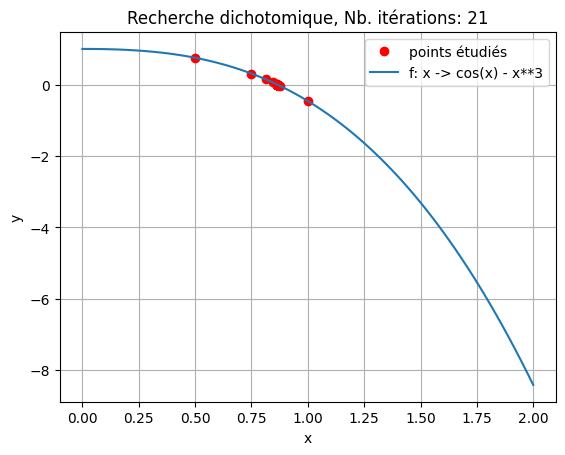

In [52]:
X = np.array(list_m_k)
Y = f(X)
plt.plot(X, Y, "ro", label="points étudiés")

x = np.linspace(a, b, 100)
y = f(x)
plt.plot(x, y, label=f"f: x -> cos(x) - x**3")

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(visible=True)
plt.title(f"Recherche dichotomique, Nb. itérations: {len(list_m_k)}")
plt.show()

# Méthode du point fixe

In [53]:
def f(x):
    return np.cos(x) - x

def g(x):
    return f(x) + x

x_0 = 0.8

tolerance = 1e-6

max_iter = 100

In [54]:
list_m_k = methode.point_fixe(g=g, x0=x_0, tol=tolerance, max_iter=max_iter)

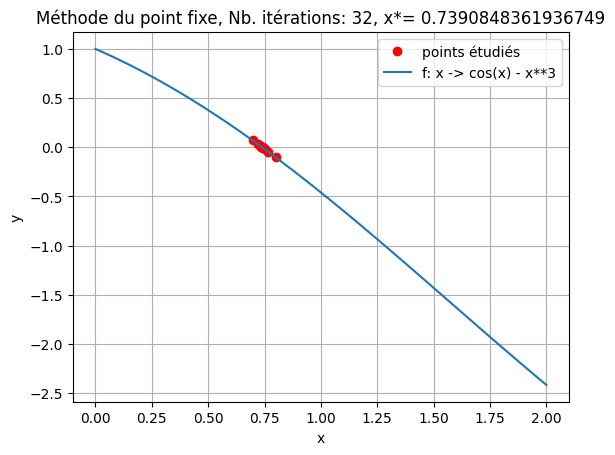

In [55]:
X = np.array(list_m_k)
Y = f(X)
plt.plot(X, Y, "ro", label="points étudiés")

x = np.linspace(a, b, 100)
y = f(x)
plt.plot(x, y, label=f"f: x -> cos(x) - x**3")

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(visible=True)
plt.title(f"Méthode du point fixe, Nb. itérations: {len(list_m_k)}, x*= {list_m_k[-1]}")
plt.show()

# Point fixe dans R²

In [56]:
def f(x):
    x1, x2 = x
    f1 = np.cos(x2) - x1
    f2 = np.sin(x1) - x2
    return np.array([f1, f2])

def g(x):
    x1, x2 = x
    return np.array([np.cos(x2), np.sin(x1)])

x_0 = np.array([0.5, 0.5])

tol = 1e-6

max_iter = 100

/tmp/ipykernel_87418/3745214174.py:11: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(X1, X2, F1, levels=[0], colors='blue', linestyles='dashed', label='f1=0')
/tmp/ipykernel_87418/3745214174.py:12: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(X1, X2, F2, levels=[0], colors='green', linestyles='dashed', label='f2=0')


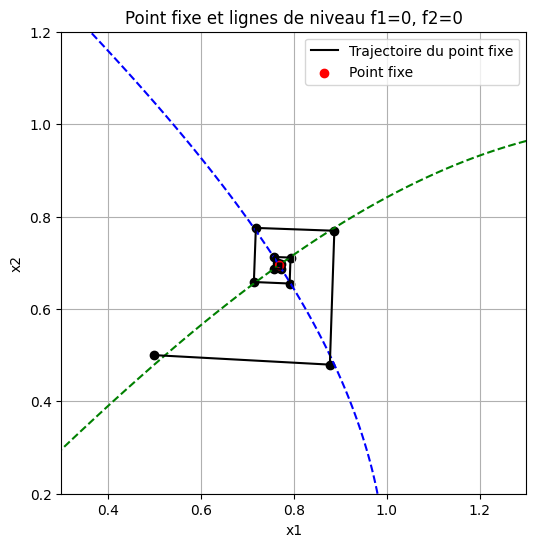

In [57]:
trajectoire = np.array(methode.point_fixe(g, x_0, tol, max_iter))

x1_vals = np.linspace(0.3, 1.3, 200)
x2_vals = np.linspace(0.2, 1.2, 200)
X1, X2 = np.meshgrid(x1_vals, x2_vals)
F1 = np.cos(X2) - X1
F2 = np.sin(X1) - X2

plt.figure(figsize=(6,6))
# Lignes de niveau f1=0 et f2=0
plt.contour(X1, X2, F1, levels=[0], colors='blue', linestyles='dashed', label='f1=0')
plt.contour(X1, X2, F2, levels=[0], colors='green', linestyles='dashed', label='f2=0')

plt.plot(trajectoire[:,0], trajectoire[:,1], '-', color='black', label='Trajectoire du point fixe')
plt.scatter(trajectoire[:-1,0], trajectoire[:-1,1], color='black')
plt.scatter([trajectoire[-1,0]], [trajectoire[-1,1]], color='red', label='Point fixe')

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Point fixe et lignes de niveau f1=0, f2=0')
plt.grid(True)
plt.legend()
plt.show()

# Méthode de Newton

In [58]:
def f(x):
    return np.cos(x) - x**3

x_0 = 0.8
tolerance = 1e-6

In [59]:
list_x_k = methode.newton(f=f, x0=x_0, tol=tol, max_iter=200)

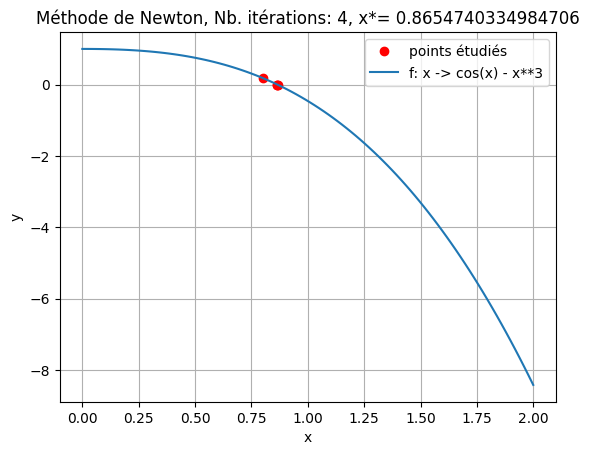

In [60]:
X = np.array(list_x_k)
Y = f(X)
plt.plot(X, Y, "ro", label="points étudiés")

x = np.linspace(a, b, 100)
y = f(x)
plt.plot(x, y, label=f"f: x -> cos(x) - x**3")

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(visible=True)
plt.title(f"Méthode de Newton, Nb. itérations: {len(list_x_k)}, x*= {list_x_k[-1]}")
plt.show()

# Méthode de Newton n-dimension

In [70]:
def f(u: np.ndarray) -> np.ndarray:
    x, y = u
    return np.array([
        x**2 + y**2 - 4,
        x - y
    ])
    
def J(u: np.ndarray) -> np.ndarray:
    x, y = u
    return np.array([
        [2*x, 2*y],
        [1, -1]
    ])

x_0 = np.array([1.5, 1.0])

tolerence = 1e-6

max_iter = 100

In [74]:
list_x_k = np.array(methode.newton_nD(f=f, J=J, x0=x_0, tol=tolerence, max_iter=max_iter))

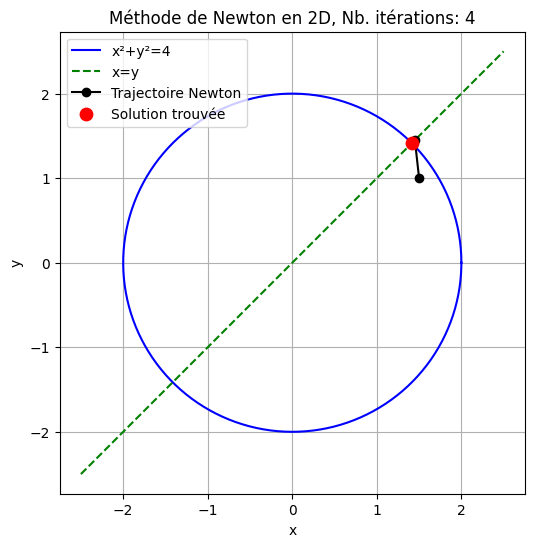

In [75]:
plt.figure(figsize=(6,6))

# Cercle x^2+y^2=4
theta = np.linspace(0, 2*np.pi, 300)
plt.plot(2*np.cos(theta), 2*np.sin(theta), 'b-', label='x²+y²=4')

# Ligne x=y
xx = np.linspace(-2.5, 2.5, 200)
plt.plot(xx, xx, 'g--', label='x=y')

# Trajectoire de Newton
plt.plot(list_x_k[:,0], list_x_k[:,1], 'ko-', label='Trajectoire Newton')

# Solution finale
plt.scatter(list_x_k[-1,0], list_x_k[-1,1], color='red', s=80, zorder=5, label='Solution trouvée')

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Méthode de Newton en 2D, Nb. itérations: {len(list_x_k)}")
plt.legend()
plt.axis("equal")
plt.grid(True)
plt.show()